In [1]:
import numpy as np
import tqdm as tqdm
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from numba import njit, prange

In [2]:
MU_0 = 4e-7 * np.pi # магнитная постоянная
EPS_0 = 8.8541878188e-12 # электрическая постоянная
ETA_0 = np.sqrt(MU_0/EPS_0) # волновое сопротивление свободного пространства
C = 1/np.sqrt(MU_0*EPS_0) # скорость света в вакууме

In [3]:
nlamb = 30 # количество точек на одну длину волны
f = 100e6 # частота
lamb = C/f # длина волны
t = 1/f # период
dx = lamb/nlamb # шаг вдоль оси x
dy = lamb/nlamb # шаг вдоль оси y
dz = lamb/nlamb # шаг вдоль оси z
dt = dx/C/np.sqrt(3)/4 # шаг по времени
N_lamb = 5 # количество длин волн в расчетной области
N_t = 5 # количество периодов для моделирования
nx = int(N_lamb*nlamb) # количество точек вдоль оси x
ny = int(N_lamb*nlamb) # количество точек вдоль оси y
nz = int(N_lamb*nlamb) # количество точек вдоль оси z
nt = int(N_t*t/dt) # количество временных шагов
print(f"Шаг по времени: {dt:.2e} с, количество временных шагов: {nt}")
print(f"Размер расчетной области: {nx*dx:.2f} м x {ny*dy:.2f} м x {nz*dz:.2f} м, количество точек: {nx} x {ny} x {nz}")

Шаг по времени: 4.81e-11 с, количество временных шагов: 1039
Размер расчетной области: 14.99 м x 14.99 м x 14.99 м, количество точек: 150 x 150 x 150


In [4]:
# Крайние слои массивов заполнены нулями для реализации сдвига по индексам
Ex = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Ey = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Ez = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hx = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hy = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hz = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
sigm = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
mu = np.ones((nx+2, ny+2, nz+2), dtype=np.float32)*MU_0
eps = np.ones((nx+2, ny+2, nz+2), dtype=np.float32)*EPS_0

In [5]:
Ez_time = np.zeros((nt, nx, ny), dtype=np.float32) # массив для сохранения Ez в центре расчетной области в каждый момент времени

In [6]:
c_1 = (1 - sigm*dt/(2*eps)) / (1 + sigm*dt/(2*eps))
c_2 = 1/(1 + sigm*dt/(2*eps))

In [7]:
@njit(parallel=True, fastmath=True)
def Next_step_Hfield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps, dx=dx, dy=dy, dz=dz, dt=dt, c_1=c_1, c_2=c_2):
    # обновление магнитного поля
    for i in prange(1, nx+1):
        for j in range(1, ny+1):
            for k in range(1, nz+1):
                Hx[i, j, k] = Hx[i, j, k] + dt/mu[i, j, k] * ((Ey[i, j, k] - Ey[i, j, k-1])/dz - (Ez[i, j+1, k] - Ez[i, j, k])/dy)
                Hy[i, j, k] = Hy[i, j, k] + dt/mu[i, j, k] * ((Ez[i+1, j, k] - Ez[i, j, k])/dx - (Ex[i, j, k] - Ex[i, j, k-1])/dz)
                Hz[i, j, k] = Hz[i, j, k] + dt/mu[i, j, k] * ((Ex[i, j+1, k] - Ex[i, j, k])/dy - (Ey[i+1, j, k] - Ey[i, j, k])/dx)
    return (Ez[1:-1, 1:-1, nz//2+1])
@njit(parallel=True, fastmath=True)
def Next_step_Efield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps, dx=dx, dy=dy, dz=dz, dt=dt, c_1=c_1, c_2=c_2):
    # обновление электрического поля
    for i in prange(1, nx+1):
        for j in range(1, ny+1):
            for k in range(1, nz+1):
                    Ex[i, j, k] = c_1[i, j, k]*Ex[i, j, k] - dt/eps[i, j, k]*c_2[i, j, k] * ((Hy[i, j, k+1] - Hy[i, j, k])/dz - (Hz[i, j, k] - Hz[i, j-1, k])/dy)
                    Ey[i, j, k] = c_1[i,j,k]*Ey[i, j, k] - dt/eps[i, j, k]*c_2[i, j, k] * ((Hz[i, j, k] - Hz[i-1, j, k])/dx - (Hx[i, j, k+1] - Hx[i, j, k])/dz)
                    Ez[i, j, k] = c_1[i,j,k]*Ez[i, j, k] - dt/eps[i, j, k]*c_2[i, j, k] * ((Hx[i, j, k] - Hx[i, j-1, k])/dy - (Hy[i, j, k] - Hy[i-1, j, k])/dx)
    return (Ez[1:-1, 1:-1, nz//2+1]) # сохраняем сечение Ez для визуализации

@njit(parallel=True, fastmath=True)
def PGU_x_max(Ey, Ez, E_y_old, E_z_old, dx=dx, dt=dt):
     for j in prange(1, ny+1):
        for k in range(1, nz+1):
            Ey[nx+1, j, k] = E_y_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Ey[nx, j, k] - E_y_old[0, j, k])
            Ez[nx+1, j, k] = E_z_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Ez[nx, j, k] - E_z_old[0, j, k])

In [8]:
Ey_old_xmax = np.zeros((2, ny+2, nz+2), dtype=np.float32)
Ez_old_xmax = np.zeros((2, ny+2, nz+2), dtype=np.float32)
for i_t in tqdm.tqdm(range(nt)):
    Ey_old_xmax[0] = Ey[-1, :, :].copy()
    Ez_old_xmax[1] = Ez[-2, :, :].copy()
    Ez_time[i_t]= Next_step_Efield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps)
    PGU_x_max(Ey, Ez, Ey_old_xmax, Ez_old_xmax)
    Ez[nx//2+1, ny//2+1, nz//2+1] = 1.0 * np.sin(2*np.pi*f*dt*i_t) # источник в центре расчетной области
    Ez_time[i_t] = Next_step_Hfield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps)
    

100%|██████████| 1039/1039 [00:37<00:00, 27.52it/s]


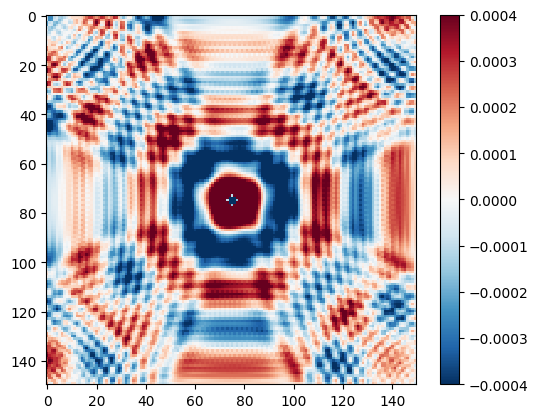

In [9]:
da = 6  # сохраняем каждый n-ый кадр
data = Ez_time[::da]  # сечение Ez
fig, ax = plt.subplots()
norm = Normalize(vmin=-4e-4, vmax=4e-4)
im = ax.imshow(data[0], cmap='RdBu_r', norm=norm, interpolation="nearest", animated=True)
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(data[frame])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(data), blit=True)

# Сохраняем анимацию в GIF
ani.save("heatmap.gif", writer='pillow', fps=30, dpi=100)

plt.show()

In [10]:
# da = 2 # сохраняем каждый n-ый кадр для анимации
# data = Ez_time[::da] # сечение Ez в середине моделирования
# fig, ax = plt.subplots()
# norm = Normalize(vmin=-4e-4, vmax=4e-4)
# im = ax.imshow(data[0], cmap='RdBu_r', norm=norm, interpolation="nearest", animated=True)
# fig.colorbar(im, ax=ax)

# def update(frame):
#     im.set_array(data[frame]) # отображаем каждый второй пиксель для ускорения анимации
#     return im

# ani = animation.FuncAnimation(fig, update, frames=len(data), blit=False)

# ani.save("heatmap03.mp4", writer="ffmpeg", fps=20, dpi=100, codec="libx264", extra_args=["-preset", "ultrafast", "-pix_fmt", "yuv420p",
#         "-profile:v", "high",
#         "-level", "4.0"])